# Yield-Curve PCA — Level, Slope, Curvature

PCA on **daily changes** in the US Treasury constant-maturity curve. The first three
principal components come out as *level* (parallel shift), *slope* (steepen/flatten),
and *curvature* (belly vs wings) — the Litterman–Scheinkman decomposition.

Two standard method choices baked in:
- PCA on **changes**, not levels — yield *levels* are near-unit-root, so a PCA on
  levels just returns a degenerate "everything's correlated" PC1.
- **Covariance**, not correlation — intermediate tenors genuinely move more, and that
  is exactly what produces the level/slope/curvature shapes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)

In [2]:
FILE = "par-yield-curve-rates-2020-2023.csv"

TMAP = {"1 mo":"1M","3 mo":"3M","6 mo":"6M","1 yr":"1Y","2 yr":"2Y","3 yr":"3Y",
        "5 yr":"5Y","7 yr":"7Y","10 yr":"10Y","20 yr":"20Y","30 yr":"30Y"}

raw = pd.read_csv(FILE)
raw["date"] = pd.to_datetime(raw["date"])
yields = (raw.set_index("date")[list(TMAP)]
             .rename(columns=TMAP)
             .sort_index())                    # Treasury exports newest-first

changes = yields.diff().dropna() * 100.0       # daily changes in bp
print(yields.shape, "|", yields.index.min().date(), "->", yields.index.max().date())
yields.tail()

(1001, 11) | 2020-01-02 -> 2023-12-29


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,,
2023-12-22,5.54,5.44,5.31,4.82,4.31,4.04,3.87,3.92,3.90,4.21,4.05
2023-12-26,5.53,5.45,5.28,4.83,4.26,4.05,3.89,3.91,3.89,4.20,4.04
2023-12-27,5.55,5.44,5.26,4.79,4.20,3.97,3.78,3.81,3.79,4.10,3.95
2023-12-28,5.57,5.45,5.28,4.82,4.26,4.02,3.83,3.84,3.84,4.14,3.98
2023-12-29,5.60,5.40,5.26,4.79,4.23,4.01,3.84,3.88,3.88,4.20,4.03


# Plotting some treasury yield curves!

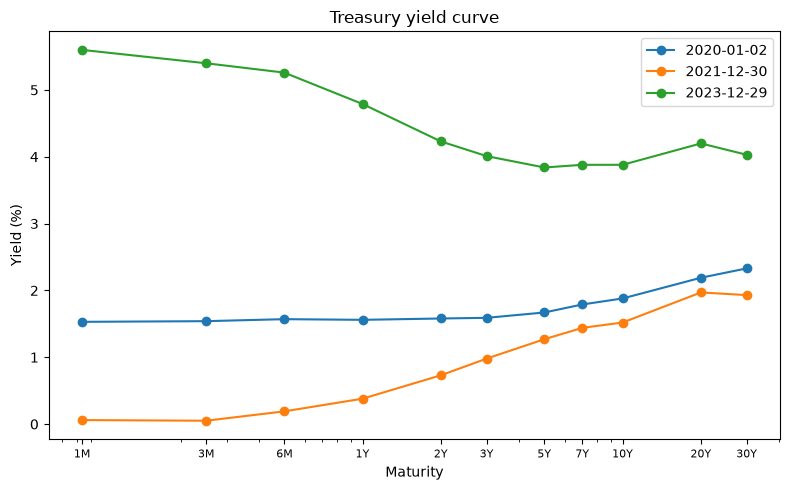

In [3]:
import matplotlib.pyplot as plt

MATS = [1/12, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]   # years, matching the 11 tenors

days = yields.iloc[[0, len(yields)//2, -1]]           # first, middle, last — change as you like

plt.figure(figsize=(8, 5))
for date, row in days.iterrows():
    plt.plot(MATS, row.values, marker="o", label=date.date())
plt.xscale("log")
plt.xticks(MATS, yields.columns, fontsize=8)
plt.xlabel("Maturity"); plt.ylabel("Yield (%)")
plt.title("Treasury yield curve")
plt.legend(); plt.tight_layout(); plt.show()

# Finding the covariance matrix and the eigendecomposition

In [4]:
cov=np.cov(changes.values, rowvar=False)


In [5]:
eigvals, eigvecs = np.linalg.eigh(cov)

# eigh returns them ascending — flip to descending (largest variance first)
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

print(eigvals)

[281.08476063  50.25012232  44.7422684   18.86859885   6.32621714
   2.81494552   2.41681869   1.09513907   0.69579888   0.62154121
   0.34205254]


In [6]:
print("The variance explained by eigvals")
print(eigvals*100/eigvals.sum())

The variance explained by eigvals
[68.68151137 12.27834031 10.93252658  4.61043809  1.54577628  0.68781642
  0.59053632  0.26759119  0.17001462  0.15187017  0.08357865]


In [7]:
eigvecs.shape

(11, 11)

Plotting the factor loadings which are the eigenvectors. By using just the top three factors I can explain about 92 % of the variance. Again factor loadings are the eigenvectors.

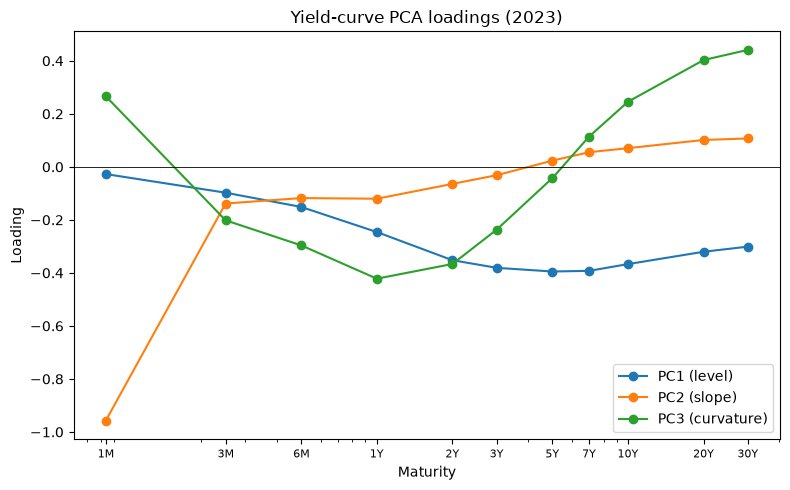

In [8]:
import matplotlib.pyplot as plt

MATS = [1/12, 0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
names = ["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"]

plt.figure(figsize=(8, 5))
for m in range(3):
    plt.plot(MATS, eigvecs[:, m], marker="o", label=names[m])
plt.axhline(0, color="k", lw=0.6)
plt.xscale("log")
plt.xticks(MATS, yields.columns, fontsize=8)
plt.xlabel("Maturity"); plt.ylabel("Loading")
plt.title("Yield-curve PCA loadings (2020-2023)")
plt.legend(); plt.tight_layout(); plt.show()

Now, we calculate the scores, which are the projection of the data points( which is T) onto the factor loadings.( Which are the eigenvectors). So, we do the projection onto the eigenvectors and find the value.

In [9]:
scores = changes.values @ eigvecs      # (T × 11) @ (11 × 11) = (T × 11)

# keep the top 3, put back on the dates for easy plotting
import pandas as pd
scores3 = pd.DataFrame(scores[:, :3], index=changes.index,
                       columns=["level", "slope", "curvature"])
print(scores3.head())

                level     slope  curvature
date                                      
2020-01-03  18.334726 -0.686255  -4.687782
2020-01-06  -4.254550 -2.003417   0.976193
2020-01-07  -2.900452  3.244358   3.739249
2020-01-08 -11.946215  2.784626   0.745200
2020-01-09   3.219330 -3.017269   0.885812


# Factor Scores

The factor scores are the projection of the data point onto the eigenvectors. For the 3D plane, the numbers we obtain are simply the projection onto the 3 eigenvectors which are the coordinate axes. Here, it is the data points which are indexed by $T$ onto the various factors.

We plot factor scores for the top 3 factor loadings. We observe that the factor scores for PC1 are changing values the most obviously since the highest variance. The least is for the curvature. 

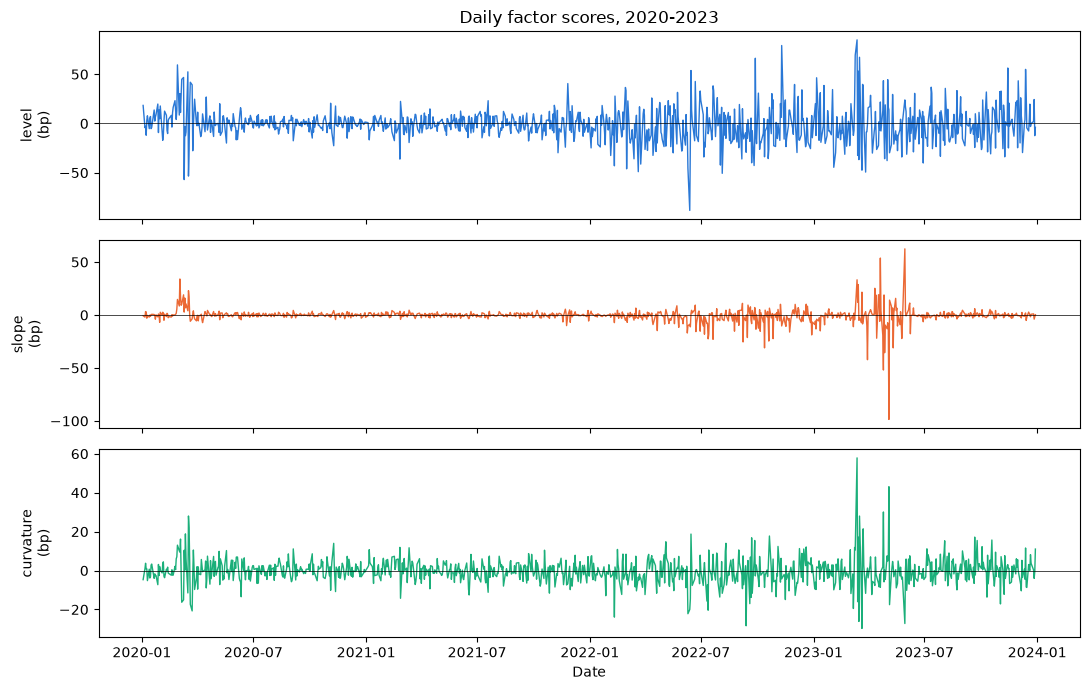

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, col, color in zip(axes, ["level", "slope", "curvature"], ["#2a78d6", "#eb6834", "#1baf7a"]):
    ax.plot(scores3.index, scores3[col], color=color, lw=1)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(f"{col}\n(bp)")
axes[0].set_title("Daily factor scores, 2020-2023")
axes[-1].set_xlabel("Date")
plt.tight_layout(); plt.show()

Computing the variances, we can see that the level factor has the highest variance!

In [11]:
for i in range(3):
    print(np.var(scores3.iloc[:,i]))

280.80367586733536
50.199872196159546
44.69752613221675


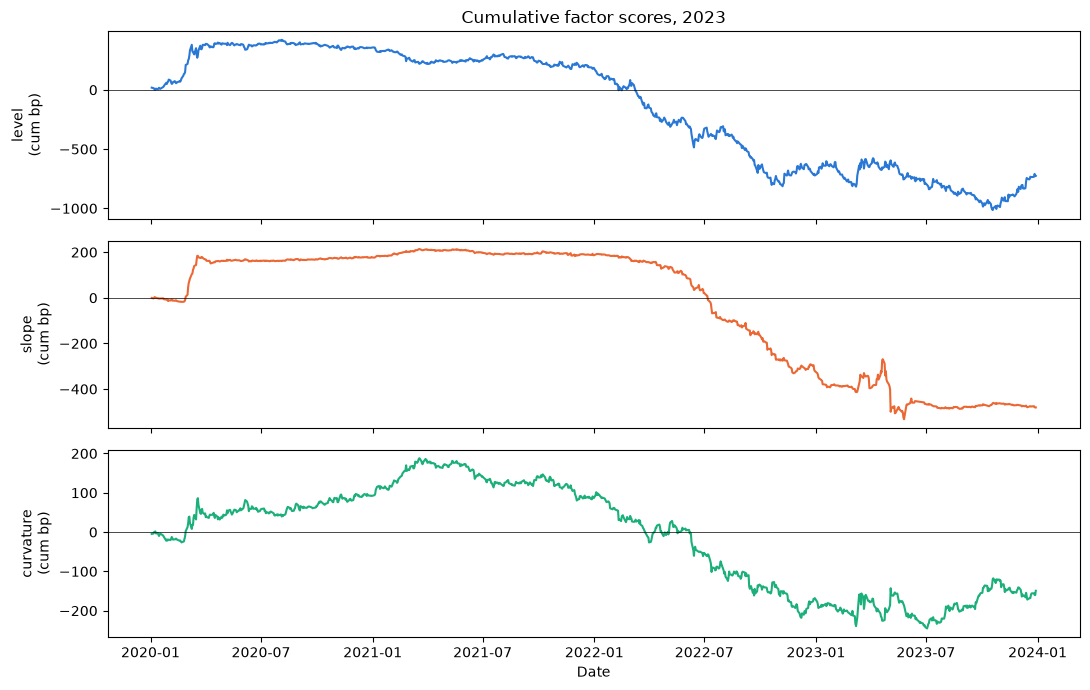

In [12]:
cum = scores3.cumsum()

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, col, color in zip(axes, ["level", "slope", "curvature"], ["#2a78d6", "#eb6834", "#1baf7a"]):
    ax.plot(cum.index, cum[col], color=color, lw=1.5)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(f"{col}\n(cum bp)")
axes[0].set_title("Cumulative factor scores, 2020-2023")
axes[-1].set_xlabel("Date")
plt.tight_layout(); plt.show()

# Analyzing the Residual

Next we try to build a portfolio which is the residual. If these three factors explain the most, then whaever is remaining should be mean reverting. So, I can look for any substantial movement from the mean and buy portolios to lock in a proft.

In [13]:
recon_full = scores @ eigvecs.T          # ALL 11 factors
print("full reconstruction error:", np.abs(changes.values - recon_full).max())   # expect ~1e-13

recon3 = scores[:, :3] @ eigvecs[:, :3].T
residual = changes.values - recon3

full reconstruction error: 1.4210854715202004e-13


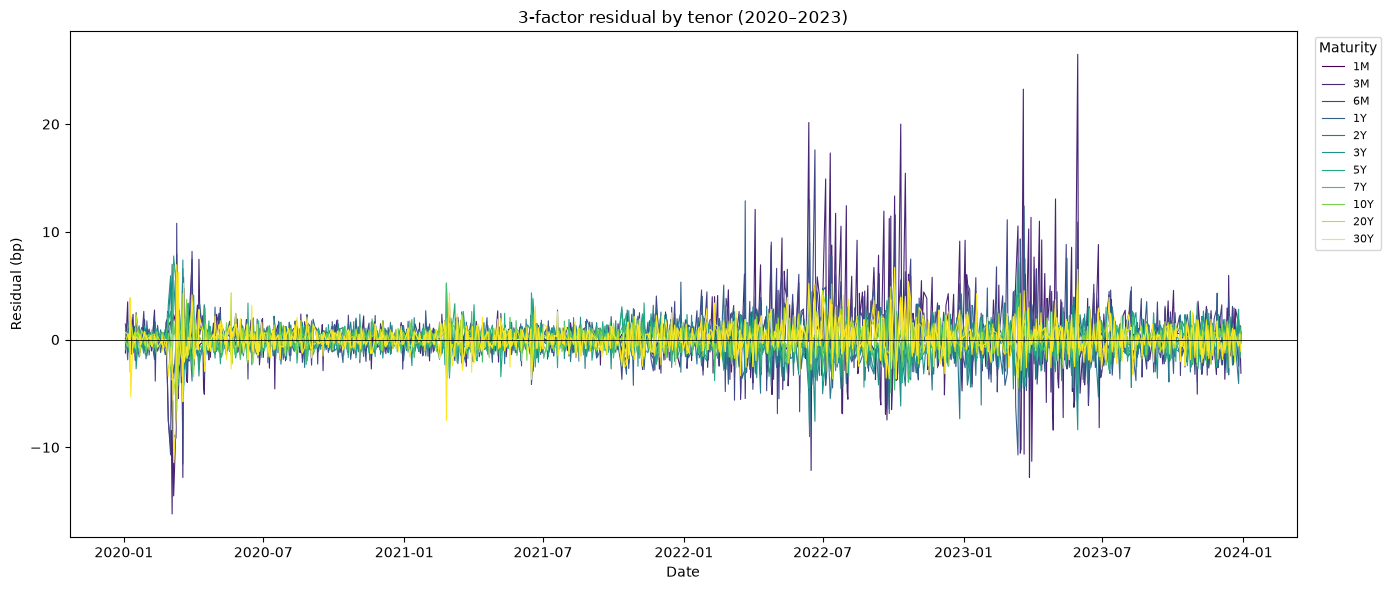

In [14]:
maturities = list(TMAP.values())
colors = plt.cm.viridis(np.linspace(0, 1, len(maturities)))   # short -> long by color

fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(maturities):
    ax.plot(changes.index, residual[:, i], color=colors[i], lw=0.8, label=m)

ax.axhline(0, color="k", lw=0.6)
ax.set_title("3-factor residual by tenor (2020–2023)")
ax.set_xlabel("Date")
ax.set_ylabel("Residual (bp)")
ax.legend(title="Maturity", bbox_to_anchor=(1.01, 1), loc="upper left", ncol=1, fontsize=8)
plt.tight_layout()
plt.show()

Residuals Per Tenor Sorted by Year.

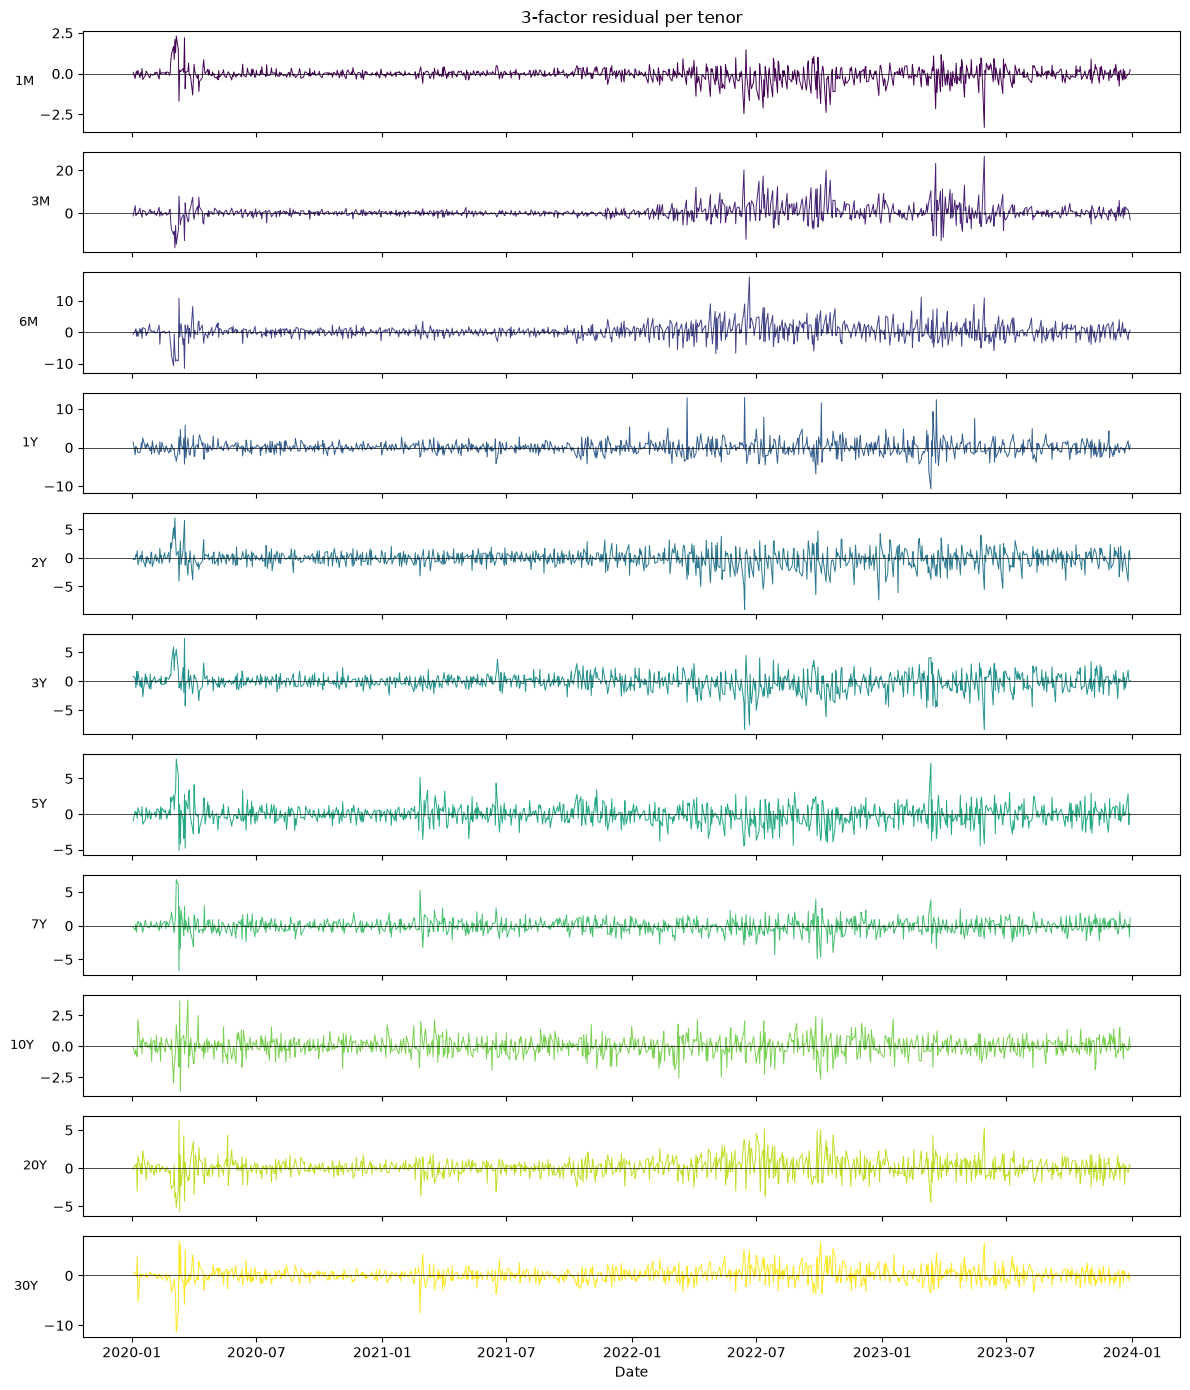

In [15]:
fig, axes = plt.subplots(11, 1, figsize=(12, 14), sharex=True)
for i, (m, ax) in enumerate(zip(maturities, axes)):
    ax.plot(changes.index, residual[:, i], color=colors[i], lw=0.7)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_ylabel(m, rotation=0, ha="right", va="center", fontsize=9)
axes[0].set_title("3-factor residual per tenor")
axes[-1].set_xlabel("Date")
plt.tight_layout(); plt.show()

In [17]:
maturities = list(TMAP.values())

def mean_reversion_table(residual, maturities):
    rows = {}
    for i, m in enumerate(maturities):
        r = residual[:, i]
        # lag-1 autocorrelation = AR(1) phi:  r_t = phi * r_{t-1} + noise
        phi = np.corrcoef(r[:-1], r[1:])[0, 1]
        # half-life only defined when 0 < phi < 1 (smooth reversion)
        if 0 < phi < 1:
            half_life = -np.log(2) / np.log(phi)
        else:
            half_life = np.nan          # phi<=0: sub-daily overshoot; phi>=1: trends
        rows[m] = {"autocorr": phi, "half_life": half_life}
    return pd.DataFrame(rows).T.round(3)

mr = mean_reversion_table(residual, maturities)
print(mr.to_string())

     autocorr  half_life
1M      0.004      0.123
3M     -0.089        NaN
6M     -0.070        NaN
1Y     -0.126        NaN
2Y     -0.043        NaN
3Y     -0.006        NaN
5Y     -0.052        NaN
7Y     -0.097        NaN
10Y    -0.146        NaN
20Y    -0.085        NaN
30Y     0.027      0.192


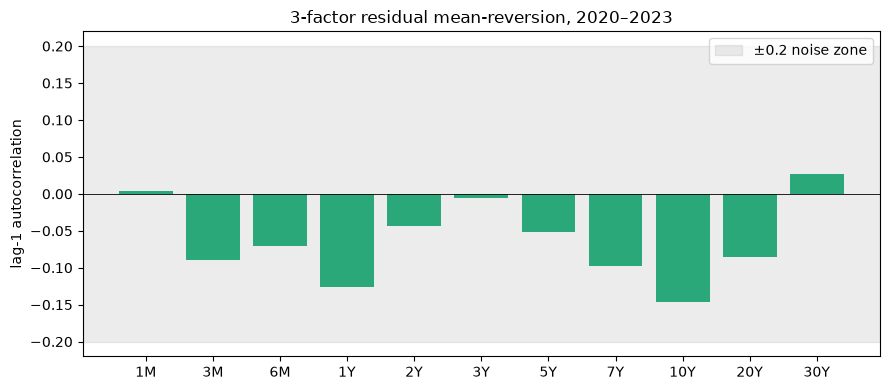

In [18]:
import matplotlib.pyplot as plt
ac = mr["autocorr"]
plt.figure(figsize=(9, 4))
plt.bar(ac.index, ac.values, color=["#1baf7a" if abs(v) < 0.2 else "#eb6834" for v in ac])
plt.axhspan(-0.2, 0.2, color="gray", alpha=0.15, label="±0.2 noise zone")
plt.axhline(0, color="k", lw=0.6)
plt.ylabel("lag-1 autocorrelation"); plt.title("3-factor residual mean-reversion, 2020–2023")
plt.legend(); plt.tight_layout(); plt.show()

THe big residual that we see for the 3months is because it is affected by the monetory policy. It means that the three factors which we have computed do not account for the change in this tenor and it has to come from the real outside factor which is the monetary policy setting by the FED. It makes more sense to trade in the belly of the curve( between 2Y-7Y). The long and short end of the yield curve are fixed.

# Key Rate Duration

In [19]:
maturities = list(TMAP.values())
V3 = eigvecs[:, :3]                      # level, slope, curvature loadings

# sample position: $ of 10Y bond, risk expressed as key-rate durations (years) per tenor
KRD = np.zeros(11)
KRD[maturities.index("10Y")] = 8.3       # a 10Y has ~8.3y duration; all risk at the 10Y point

# compress 11 tenor-risks -> 3 factor exposures (project KRD onto the loadings)
exposures = V3.T @ KRD
for name, e in zip(["level", "slope", "curvature"], exposures):
    print(f"{name:>9}: {e:+.3f}")

# variance split: lambda_m * (exposure_m)^2, as % of total risk
proj = eigvecs.T @ KRD
contrib = eigvals * proj**2
frac = contrib / contrib.sum()
print("\nrisk split:")
for name, f in zip(["level", "slope", "curvature"], frac[:3]):
    print(f"  {name:>9}: {f:6.1%}")
print(f"  {'residual':>9}: {frac[3:].sum():6.1%}")

    level: -3.044
    slope: +0.585
curvature: +2.039

risk split:
      level:  91.5%
      slope:   0.6%
  curvature:   6.5%
   residual:   1.4%


In [20]:
maturities = list(TMAP.values())
V3 = eigvecs[:, :3]

# --- your original position: long the 10Y ---
KRD_pos = np.zeros(11)
KRD_pos[maturities.index("10Y")] = 8.3

# --- hedge instrument: the 2Y (duration ~1.9). We SHORT some amount h of it. ---
KRD_hedge_unit = np.zeros(11)
KRD_hedge_unit[maturities.index("2Y")] = 1.9

# solve for h so combined LEVEL exposure = 0:
#   v1 . (KRD_pos - h * KRD_hedge_unit) = 0   ->   h = (v1.KRD_pos) / (v1.KRD_hedge_unit)
v1 = V3[:, 0]
h = (v1 @ KRD_pos) / (v1 @ KRD_hedge_unit)
print(f"hedge: short {h:.2f} units of the 2Y (duration-weighted)\n")

KRD_hedged = KRD_pos - h * KRD_hedge_unit

# --- compare risk split: before vs after ---
def risk_split(KRD):
    proj = eigvecs.T @ KRD
    contrib = eigvals * proj**2
    frac = contrib / contrib.sum()
    return frac, contrib.sum()

for label, KRD in [("BEFORE (10Y only)", KRD_pos), ("AFTER  (level-hedged)", KRD_hedged)]:
    frac, total = risk_split(KRD)
    print(f"{label}   total variance = {total:.3f}")
    for name, f in zip(["level", "slope", "curvature"], frac[:3]):
        print(f"    {name:>9}: {f:6.1%}")
    print(f"    {'residual':>9}: {frac[3:].sum():6.1%}\n")

hedge: short 4.55 units of the 2Y (duration-weighted)

BEFORE (10Y only)   total variance = 2847.867
        level:  91.5%
        slope:   0.6%
    curvature:   6.5%
     residual:   1.4%

AFTER  (level-hedged)   total variance = 1544.956
        level:   0.0%
        slope:   4.2%
    curvature:  78.5%
     residual:  17.3%



## Summary

Starting from daily Treasury par yields (2020–2023, 11 tenors), we worked with daily *changes* and their covariance, then ran PCA.

- **Factor structure.** The top 3 principal components are level, slope, and curvature, explaining ~92% of variance (level ~69%, slope ~12%, curvature ~11%). Their loadings have 0 / 1 / 2 sign changes across the curve, confirming the shapes.
- **Relative value (residual).** Reconstructing each day from the 3 factors and testing the residual for mean reversion, lag-1 autocorrelation is ≈ 0 to −0.15 at every tenor — no tradeable daily signal. The large short-end residual is monetary-policy driven, not a dislocation. This is a descriptive/diagnostic result, not a return claim.
- **Risk decomposition & hedging.** A position's key-rate durations project onto the 3 factors to give factor exposures and a variance split. A single 10Y bond is ~90%+ level risk; hedging the level exposure with the 2Y removes it and leaves a cleaner curvature/slope position at lower total variance.

All figures reproduce by re-running top to bottom.